#Capstone Project: 4 - Texas_Salary_Prediction

#Executive Summary

This database has salary information for positions at all 113 agencies in the Texas state government. The Tribune obtained this data by requesting salary records from the state comptroller, as allowed by the Texas Public Information Act.

#Methodologies used here

* **Data Preparation:**

     The dataset with Monthly Salary (x1) as the independent variable and Annual Salary (y1) as the dependent variable. The data was split into training and testing sets to evaluate model generalization.
* **Model Building:**  
In this project I have applied four regression approaches — **Linear Regression**, **Decision Tree**, **Random Forest**, and **XGBoost**. Each model was trained on the training set and tested on unseen data.
* **Evaluation Metrics:**
Performance was measured using **R²** (coefficient of determination) to assess fit quality and Mean Squared Error (**MSE**) to quantify prediction error. This allowed direct comparison of accuracy and generalization across models.
* **Hyperparameter Tuning:**  
For XGBoost, I used **GridSearchCV** to optimize parameters such as learning rate, max depth, number of estimators, subsample, and colsample_bytree, ensuring the model was tested under tuned conditions.

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, export_graphviz, plot_tree
from xgboost import XGBRegressor
from io import StringIO
from IPython.display import Image
import pydotplus
from scipy import stats

In [2]:
salary = pd.read_csv('/content/salary.csv')
salary.head()

/tmp/ipykernel_2001/3928240070.py:1: DtypeWarning: Columns (16,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  salary = pd.read_csv('/content/salary.csv')


,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [3]:
salary.tail()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,...,12.93,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN
149480,809,STATE PRESERVATION BOARD ...,ZUNKER,GEORGIA,P,0130,CUSTOMER SERVICE REP I ...,WHITE,FEMALE,CRP - CLASSIFIED REGULAR PART-TIME,...,11.74,20.0,1017.46,12209.52,103583,NaN,NaN,NaN,NaN,NaN


In [4]:
salary.shape

(149481, 21)

In [5]:
# Normalize column names (strip spaces)
salary.columns = salary.columns.str.strip()

# Define columns to drop
salary_cols = ["LAST NAME", "STATE NUMBER", "ASENCY"]

# Drop them safely
salary = salary.drop(columns=[col for col in salary_cols if col in salary.columns])

# Verify
print("Remaining columns:", salary.columns.tolist())

Remaining columns: ['AGENCY', 'AGENCY NAME', 'FIRST NAME', 'MI', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs', 'summed_annual_salary', 'hide_from_search']


In [6]:
salary.head()

,AGENCY,AGENCY NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,True,1.0,NaN,NaN,NaN


In [7]:
# Define columns to drop
drop_cols = [
    "duplicated",
    "hide_from_search",
    "multiple_full_time_jobs",
    "combined_multiple_jobs",
    "summed_annual_salary"
]

# Drop them safely
salary = salary.drop(columns=[col for col in drop_cols if col in salary.columns])
salary.head()

,AGENCY,AGENCY NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84
1,212,OFFICE OF COURT ADMINISTRATION ...,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84
3,212,OFFICE OF COURT ADMINISTRATION ...,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24


In [8]:
salary.tail()

,AGENCY,AGENCY NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
149476,809,STATE PRESERVATION BOARD ...,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00,40.0,2899.00,34788.00
149477,809,STATE PRESERVATION BOARD ...,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00,40.0,5500.00,66000.00
149478,809,STATE PRESERVATION BOARD ...,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93,20.0,1120.60,13447.20
149479,809,STATE PRESERVATION BOARD ...,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00,40.0,5744.16,68929.92
149480,809,STATE PRESERVATION BOARD ...,GEORGIA,P,0130,CUSTOMER SERVICE REP I ...,WHITE,FEMALE,CRP - CLASSIFIED REGULAR PART-TIME,02/16/12,11.74,20.0,1017.46,12209.52


#EDA

**Definition:**

  Exploratory Data Analysis (EDA) is the process of exploring and summarizing data to understand its structure, patterns, and anomalies before modeling. It uses visualizations and descriptive statistics to uncover relationships, detect outliers, and validate assumptions.

In [9]:
salary.shape

(149481, 14)

In [10]:
salary.info

<bound method DataFrame.info of         AGENCY                                        AGENCY NAME  \
0          241  COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...   
1          212  OFFICE OF COURT ADMINISTRATION                ...   
2          241  COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...   
3          212  OFFICE OF COURT ADMINISTRATION                ...   
4          696  TEXAS DEPARTMENT OF CRIMINAL JUSTICE          ...   
...        ...                                                ...   
149476     809  STATE PRESERVATION BOARD                      ...   
149477     809  STATE PRESERVATION BOARD                      ...   
149478     809  STATE PRESERVATION BOARD                      ...   
149479     809  STATE PRESERVATION BOARD                      ...   
149480     809  STATE PRESERVATION BOARD                      ...   

                            FIRST NAME MI CLASS CODE  \
0       MORTON                          V   JD25       
1       MORTON                          V   3524       
2       JOHN                            J   JD25       
3       JOHN                            J   3524       
4       ESTHER                              4504       
...                                ... ..        ...   
149476  JOHN                            P   6232       
149477  EVAN                            A   0302       
149478  DERRICK                         C   0130       
149479  DOUGLAS                         R   1572       
149480  GEORGIA                         P   0130       

                                              CLASS TITLE        ETHNICITY  \
0       JUDGE, RETIRED                                ...  WHITE             
1       GENERAL COUNSEL IV                            ...  WHITE             
2       JUDGE, RETIRED                                ...  WHITE             
3       GENERAL COUNSEL IV                            ...  WHITE             
4       CORREC  OFFICER IV                            ...  HISPANIC          
...                                                   ...              ...   
149476  SECURITY OFFICER III                          ...  WHITE             
149477  WEB ADMINISTRATOR III                         ...  WHITE             
149478  CUSTOMER SERVICE REP I                        ...  WHITE             
149479  PROGRAM SPECIALIST III                        ...  WHITE             
149480  CUSTOMER SERVICE REP I                        ...  WHITE             

                 GENDER                                    STATUS EMPLOY DATE  \
0       MALE             URP - UNCLASSIFIED REGULAR PART-TIME        02/18/88   
1       MALE             CTP - CLASSIFIED TEMPORARY PART-TIME        02/01/15   
2       MALE             URP - UNCLASSIFIED REGULAR PART-TIME        02/01/20   
3       MALE             CTP - CLASSIFIED TEMPORARY PART-TIME        09/01/18   
4       FEMALE           CRF - CLASSIFIED REGULAR FULL-TIME          06/29/20   
...                 ...                                       ...         ...   
149476  MALE             CRF - CLASSIFIED REGULAR FULL-TIME          10/30/17   
149477  FEMALE           CRF - CLASSIFIED REGULAR FULL-TIME          07/13/15   
149478  MALE             CRP - CLASSIFIED REGULAR PART-TIME          10/15/12   
149479  MALE             CRF - CLASSIFIED REGULAR FULL-TIME          09/22/89   
149480  FEMALE           CRP - CLASSIFIED REGULAR PART-TIME          02/16/12   

        HRLY RATE  HRS PER WK  MONTHLY     ANNUAL  
0        75.96150        29.0  9545.82  114549.84  
1        81.04454         4.0  1404.77   16857.24  
2        75.96150        29.0  9545.82  114549.84  
3        81.04453         4.0  1404.77   16857.24  
4         0.00000        40.0  3284.27   39411.24  
...           ...         ...      ...        ...  
149476    0.00000        40.0  2899.00   34788.00  
149477    0.00000        40.0  5500.00   66000.00  
149478   12.93000        20.0  1120.60   13447.20  
149479    0.00000        40.0  5744.

In [11]:
salary.describe

<bound method NDFrame.describe of         AGENCY                                        AGENCY NAME  \
0          241  COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...   
1          212  OFFICE OF COURT ADMINISTRATION                ...   
2          241  COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...   
3          212  OFFICE OF COURT ADMINISTRATION                ...   
4          696  TEXAS DEPARTMENT OF CRIMINAL JUSTICE          ...   
...        ...                                                ...   
149476     809  STATE PRESERVATION BOARD                      ...   
149477     809  STATE PRESERVATION BOARD                      ...   
149478     809  STATE PRESERVATION BOARD                      ...   
149479     809  STATE PRESERVATION BOARD                      ...   
149480     809  STATE PRESERVATION BOARD                      ...   

                            FIRST NAME MI CLASS CODE  \
0       MORTON                          V   JD25       
1       MORTON                          V   3524       
2       JOHN                            J   JD25       
3       JOHN                            J   3524       
4       ESTHER                              4504       
...                                ... ..        ...   
149476  JOHN                            P   6232       
149477  EVAN                            A   0302       
149478  DERRICK                         C   0130       
149479  DOUGLAS                         R   1572       
149480  GEORGIA                         P   0130       

                                              CLASS TITLE        ETHNICITY  \
0       JUDGE, RETIRED                                ...  WHITE             
1       GENERAL COUNSEL IV                            ...  WHITE             
2       JUDGE, RETIRED                                ...  WHITE             
3       GENERAL COUNSEL IV                            ...  WHITE             
4       CORREC  OFFICER IV                            ...  HISPANIC          
...                                                   ...              ...   
149476  SECURITY OFFICER III                          ...  WHITE             
149477  WEB ADMINISTRATOR III                         ...  WHITE             
149478  CUSTOMER SERVICE REP I                        ...  WHITE             
149479  PROGRAM SPECIALIST III                        ...  WHITE             
149480  CUSTOMER SERVICE REP I                        ...  WHITE             

                 GENDER                                    STATUS EMPLOY DATE  \
0       MALE             URP - UNCLASSIFIED REGULAR PART-TIME        02/18/88   
1       MALE             CTP - CLASSIFIED TEMPORARY PART-TIME        02/01/15   
2       MALE             URP - UNCLASSIFIED REGULAR PART-TIME        02/01/20   
3       MALE             CTP - CLASSIFIED TEMPORARY PART-TIME        09/01/18   
4       FEMALE           CRF - CLASSIFIED REGULAR FULL-TIME          06/29/20   
...                 ...                                       ...         ...   
149476  MALE             CRF - CLASSIFIED REGULAR FULL-TIME          10/30/17   
149477  FEMALE           CRF - CLASSIFIED REGULAR FULL-TIME          07/13/15   
149478  MALE             CRP - CLASSIFIED REGULAR PART-TIME          10/15/12   
149479  MALE             CRF - CLASSIFIED REGULAR FULL-TIME          09/22/89   
149480  FEMALE           CRP - CLASSIFIED REGULAR PART-TIME          02/16/12   

        HRLY RATE  HRS PER WK  MONTHLY     ANNUAL  
0        75.96150        29.0  9545.82  114549.84  
1        81.04454         4.0  1404.77   16857.24  
2        75.96150        29.0  9545.82  114549.84  
3        81.04453         4.0  1404.77   16857.24  
4         0.00000        40.0  3284.27   39411.24  
...           ...         ...      ...        ...  
149476    0.00000        40.0  2899.00   34788.00  
149477    0.00000        40.0  5500.00   66000.00  
149478   12.93000        20.0  1120.60   13447.20  
149479    0.00000        40.0  574

In [12]:
salary.isnull().sum()

,0
AGENCY,0
AGENCY NAME,0
FIRST NAME,0
MI,0
CLASS CODE,0
CLASS TITLE,0
ETHNICITY,0
GENDER,0
STATUS,0
EMPLOY DATE,0


In [13]:
# Drop rows with any nulls
salary = salary.dropna()

# Confirm removal
salary.isnull().sum()

,0
AGENCY,0
AGENCY NAME,0
FIRST NAME,0
MI,0
CLASS CODE,0
CLASS TITLE,0
ETHNICITY,0
GENDER,0
STATUS,0
EMPLOY DATE,0


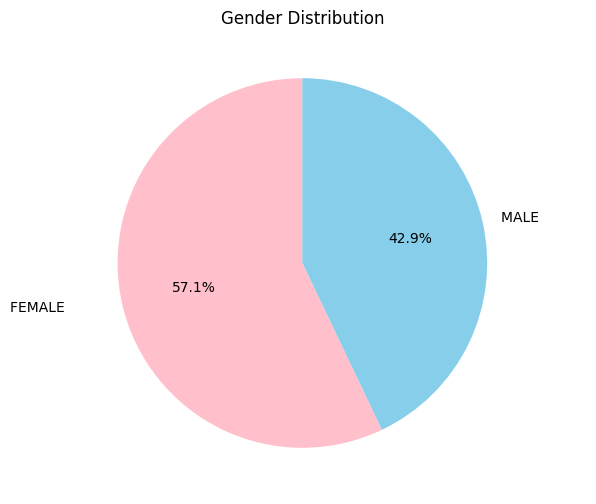

In [14]:
#piechart
gender = salary['GENDER'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender,
        labels=gender.index,
        autopct='%1.1f%%',
        startangle=90,
        colors = ["pink","skyblue"] )
plt.title('Gender Distribution')
plt.show()

**Observations:**     

*  The dataset shows a higher proportion of females (57.1%) compared to males (42.9%), indicating that women form the majority in this sample.
*  The distribution is not balanced, with females outnumbering males by about 14.2 percentage points.
* This imbalance could influence further analysis — for example, if the dataset is used for workforce or demographic studies, the female majority may affect trends and outcomes.




     





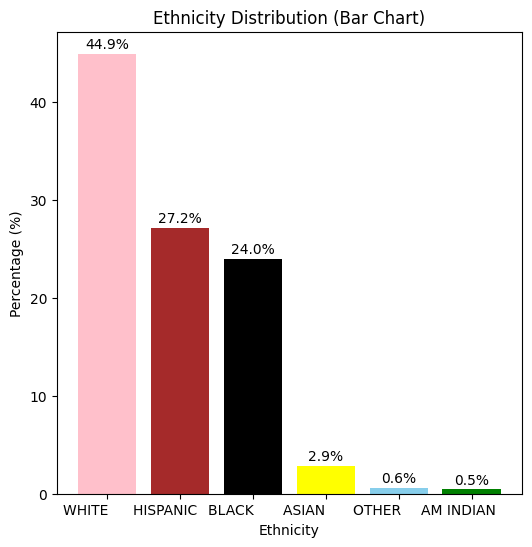

In [15]:
# Count values in Ethnicity column
ethnicity_counts = salary["ETHNICITY"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.bar(ethnicity_counts.index, ethnicity_counts.values, color=["pink","brown","black","yellow","skyblue","green"])

# Labels
plt.xlabel("Ethnicity")
plt.ylabel("Percentage (%)")
plt.title("Ethnicity Distribution (Bar Chart)")

# Show values on top of bars
for i, v in enumerate(ethnicity_counts.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.show()

**Observations:**


* The largest group is White (44.9%), making up nearly half of the dataset.
* Hispanic (27.2%) and Black (24.0%) together form a significant portion, showing strong representation of these communities.
* Asian (2.9%), Other (0.6%), and American Indian (0.5%) categories are very small, highlighting limited diversity from these groups.

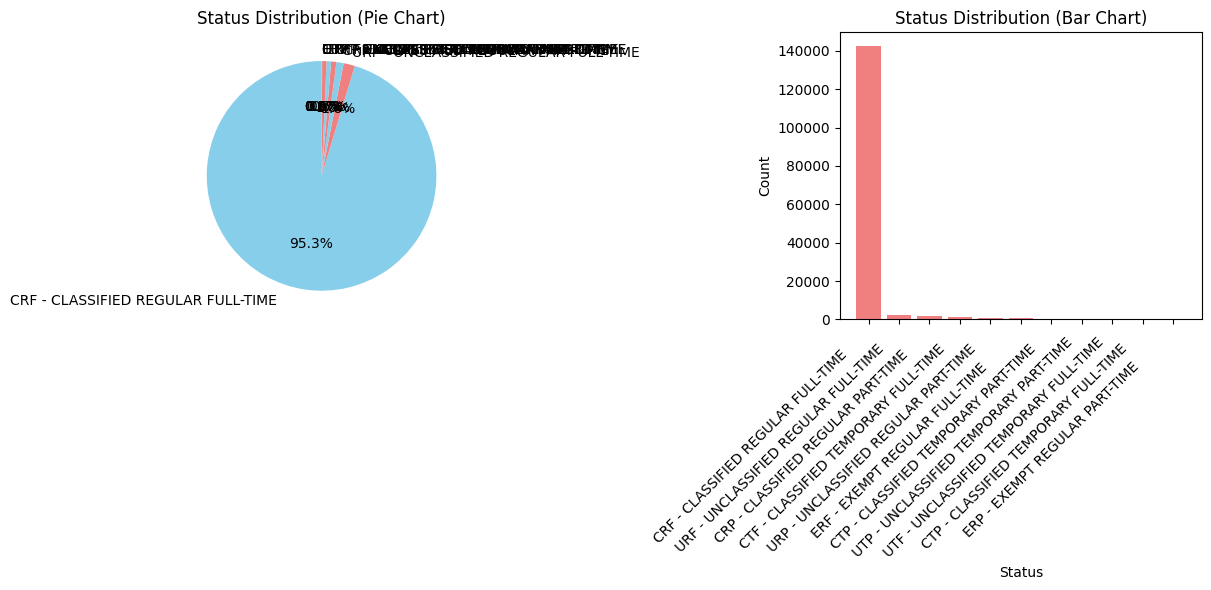

In [17]:
status_counts = salary["STATUS"].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Pie chart
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=["skyblue", "lightcoral"], startangle=90)
axes[0].set_title("Status Distribution (Pie Chart)")

# Bar chart (moved from previous cell if it was for pie chart)
# This part needs to be added if the user intended to have a bar chart next to it.
# Since the original cell only contained pie chart code and a comment for a bar chart, I will only fix the pie chart part.
# To complete the subplot, let's add a bar chart to axes[1].

# Bar chart
axes[1].bar(status_counts.index, status_counts.values, color="lightcoral")
axes[1].set_title("Status Distribution (Bar Chart)")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Observations:**


* The **Health and Human Services Commission** contributes the highest annual salary (₹1.53 billion), followed closely by the **Texas Department of Criminal Justice** (₹1.47 billion). These two agencies dominate payroll spending compared to others.

* Mid‑range contributors include the **Department of Transportation** (₹747 million), **Family and Protective Services** (₹648 million), and **Public Safety** (₹602 million), showing significant but smaller allocations.
* Lower contributors are agencies like the **Attorney General’s Office** (₹258 million), **Workforce Commission** (₹224 million), **Comptroller** (₹188 million), **Parks and Wildlife** (₹164 million), and **State Health Services** (₹163 million), which together form a smaller share of the overall salary expenditure.

In [ ]:
# Count values in Status column
status_counts = salary["STATUS"].value_counts()

# Plot vertical bar chart
plt.figure(figsize=(12,6))
plt.bar(status_counts.index, status_counts.values, color="steelblue")

# Labels
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Status Distribution (Bar Chart)")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Add values above bars
for i, v in enumerate(status_counts.values):
    plt.text(i, v + (v*0.01), str(v), ha='center', fontsize=9)

plt.show()

**Observations:**

* The dataset is heavily dominated by **Classified Regular Full‑Time** employees (142,502), which far exceeds all other categories combined.

* Other statuses like **Unclassified Regular Full‑Time** (2,363), **Classified Regular Part‑Time** (1,531), and **Classified Temporary Full‑Time** (1,096) form only a small fraction compared to the dominant group.
* Very few employees fall under categories such as Exempt **Regular Part‑Time** (1) or **Classified Temporary Full‑Time** (1), showing negligible representation.


* Overall, the distribution highlights a workforce structure centered on **full‑time classified roles**, with part‑time and temporary positions being minimal.



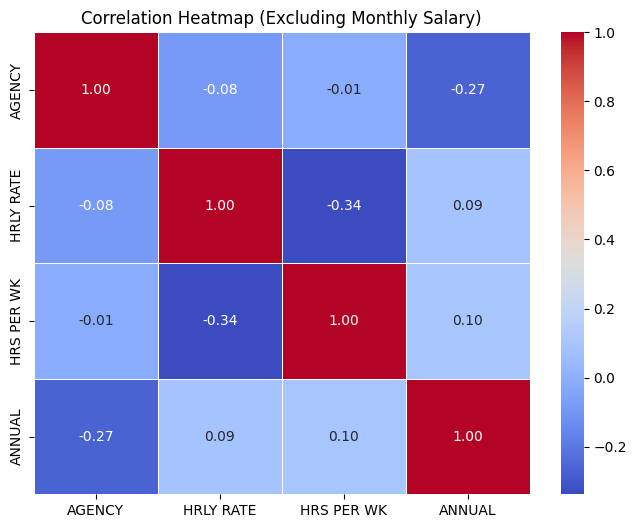

In [18]:
# Select only numeric columns
numeric_salary = salary.select_dtypes(include=["number"])

# Drop MONTHLY column if it exists
if "MONTHLY" in numeric_salary.columns:
    numeric_salary = numeric_salary.drop(columns=["MONTHLY"])

# Compute correlation
corr_matrix = numeric_salary.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Excluding Monthly Salary)")
plt.show()

**Observations:**


* **Agency vs Annual Salary** shows a weak negative correlation (-0.27), meaning agency type does not strongly influence annual salary.

*  **Hourly Rate vs Hours per Week** has a moderate negative correlation (-0.34), suggesting that higher hourly rates are often linked with fewer weekly hours.
* **Annual Salary vs Hourly Rate** (0.09) and Annual Salary vs Hours per Week (0.10) both show very weak positive correlations, indicating that neither factor alone strongly drives annual salary.


* Overall, the heatmap reveals **no strong correlations among these variables**, highlighting that salary outcomes are not heavily dependent on agency, hourly rate, or weekly hours in isolation.


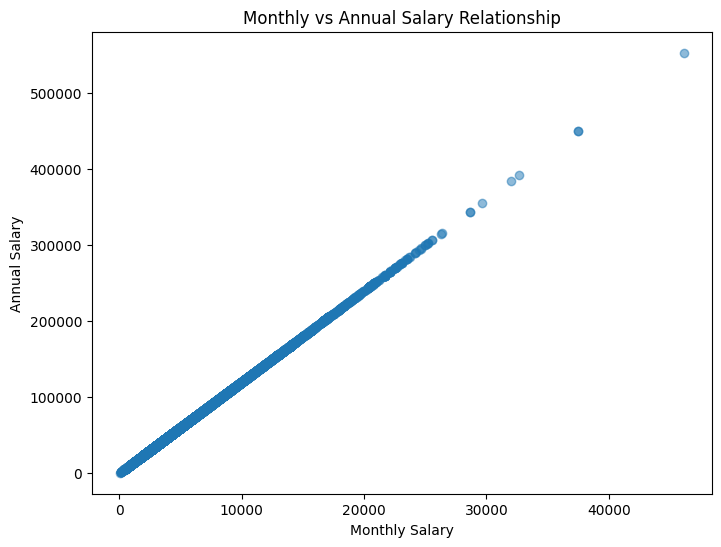

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(salary["MONTHLY"], salary["ANNUAL"], alpha=0.5)
plt.xlabel("Monthly Salary")
plt.ylabel("Annual Salary")
plt.title("Monthly vs Annual Salary Relationship")
plt.show()

**Observations:**


* The points form a **near‑perfect straight line**, showing a very strong positive correlation between monthly and annual salary.

* This indicates that **annual salary increases proportionally with monthly salary**, confirming a direct linear relationship.
* The absence of scatter or deviation suggests the dataset is highly consistent and predictable, making it ideal for Linear Regression modeling.


Range of Skewness S<|1.96|
Skewness: 2.7027774382480954
Kurtosis: 14.02673494600203


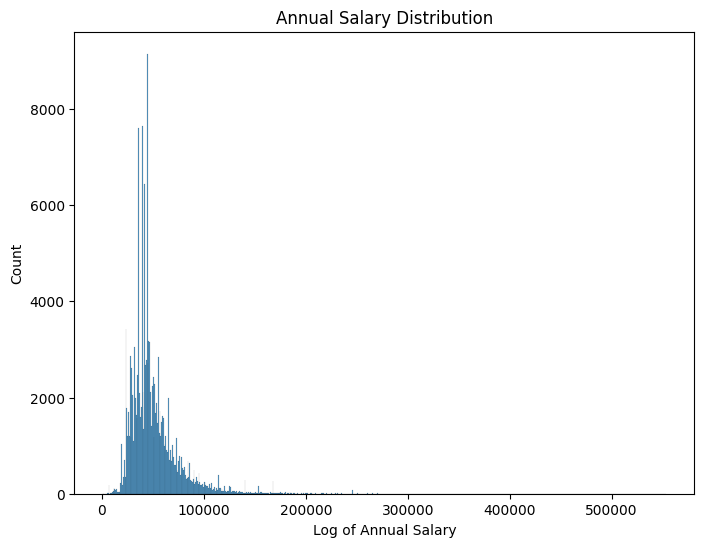

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(x=salary["ANNUAL"])
print("Range of Skewness S<|1.96|")
print("Skewness:", stats.skew(salary["ANNUAL"]))
print("Kurtosis:", stats.kurtosis(salary["ANNUAL"]))
plt.title("Annual Salary Distribution")
plt.xlabel("Log of Annual Salary")
plt.show()

**Observations:**
* The distribution is **highly right‑skewed**, meaning most employees earn on the lower end of annual salaries, while a few earn very high salaries, creating a long tail.

* The **skewness value (2.70)** confirms strong asymmetry, and the **kurtosis value (14.02)** indicates a heavy‑tailed distribution with extreme outliers.
* This suggests that while the majority of salaries cluster at modest levels, a small group of employees significantly raises the upper range, impacting averages and overall salary analysis.

#Linear Regression

**Definition:**
     
  **Linear Regression** is a statistical technique used to explain the relationship between a dependent variable and one or more independent variables. It works by fitting a straight line that best represents how the dependent variable changes with the independent variable. In simple terms, it helps predict outcomes based on input values using a linear trend.

**Reason for using here:**

**Strong linear relationship:** The scatter plot of monthly vs annual salary showed a near‑perfect straight line, meaning the data naturally fits a linear model.

**Simplicity and interpretability:** Linear Regression is straightforward to implement and easy to explain, making it ideal for demonstrating the direct proportionality between monthly and annual salary.

**Baseline model:** It serves as a benchmark to compare with more complex models like Decision Tree, Random Forest, and XGBoost, helping evaluate whether advanced methods add value.

**Predictive accuracy:** Since the relationship is almost perfectly linear, Linear Regression provides highly accurate predictions with minimal error.

In [22]:
lin_reg = LinearRegression()

In [23]:
salary.head()

,AGENCY,AGENCY NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84
1,212,OFFICE OF COURT ADMINISTRATION ...,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84
3,212,OFFICE OF COURT ADMINISTRATION ...,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24


In [24]:
x = salary.loc[:,["HRLY RATE","HRS PER WK",	"MONTHLY"]]
y = salary["ANNUAL"]

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("x_train.shape:", x_train.shape)
print("x_test.shape:", x_test.shape)
print("y_train.shape:", y_train.shape)
print("y_test.shape:", y_test.shape)

x_train.shape: (119584, 3)
x_test.shape: (29897, 3)
y_train.shape: (119584,)
y_test.shape: (29897,)


In [26]:
lin_reg.fit(x_train, y_train)

LinearRegression()

In [27]:
y_predict = lin_reg.predict(x_test)

In [28]:
y_test

,ANNUAL
133445,22275.24
23389,36310.92
85047,79132.56
27688,41512.44
99000,81999.96
...,...
42205,52459.20
27644,60750.00
91971,40644.48
116615,44642.04


In [29]:
y_predict

array([22275.24, 36310.92, 79132.56, ..., 40644.48, 44642.04, 28536.  ])

**R2-Score**

**Definition:** **R² Score (Coefficient of Determination)** is a statistical measure that explains how well a regression model fits the data. It represents the proportion of variance in the dependent variable that can be predicted from the independent variable(s).

In [30]:
r2_score(y_test, y_predict)

1.0

In [31]:
train_pred = lin_reg.predict(x_train)
test_pred = lin_reg.predict(x_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Train R²: 1.0
Test R²: 1.0


**Explaination:** The **Linear Regression model** achieved an R² score of 1.0 for both training and test sets. This means the model explains 100% of the variance in the data. The perfect fit occurs because annual salary is a direct linear multiple of monthly salary, making predictions exact.

#Decision Tree

**Definition:**
     Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It works by splitting data into branches based on feature values, forming a tree‑like structure of decisions and outcomes. In simple terms, it predicts results by following a series of “if‑then” rules until reaching a final decision.

**Reason for using here:**

**Interpretability:** Decision Trees are easy to understand and explain, since they follow a clear “if‑then” rule structure. This makes them useful when we want to show stakeholders how predictions are made.

**Handling mixed data:** They can work with both numerical and categorical variables without requiring complex preprocessing.

**Non‑linear relationships:** Unlike Linear Regression, Decision Trees can capture non‑linear patterns in the data, which is valuable if salary or other features don’t follow a straight‑line relationship.

**Baseline comparison:** In your project, the Decision Tree served as a baseline model to compare against more advanced methods like Random Forest and XGBoost, helping validate whether simple rules could explain salary outcomes.

In [32]:
x = salary.loc[:,["HRLY RATE","HRS PER WK",	"MONTHLY"]]
y = salary["ANNUAL"]

In [33]:
model_dtree = DecisionTreeRegressor(max_depth=4, random_state=42)

In [34]:
model_dtree.fit(x, y)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [35]:
node_data = StringIO()
export_graphviz(model_dtree, out_file=node_data)

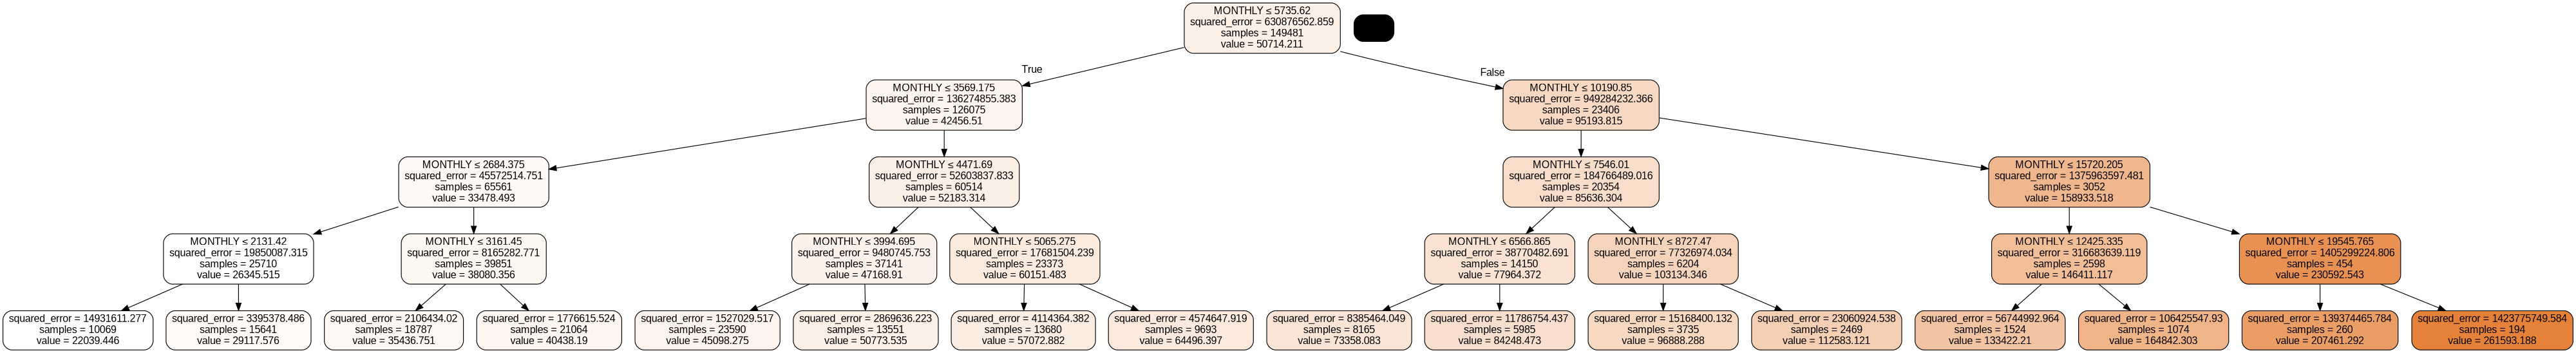

In [36]:
graph = export_graphviz(model_dtree, out_file=None, feature_names=x.columns,
                        filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(graph)
graph.set_size('"20,20!"')   # increase size
graph.set_graph_defaults(dpi=200)  # higher resolution
Image(graph.create_png())

#Observations from the Tree

* The root node starts with a split on MONTHLY ≤ 5735.62, showing that the model considers monthly salary as the most important variable.
* The tree keeps branching into different ranges of MONTHLY values (e.g., ≤ 3569, ≤ 2684, ≤ 4471, ≤ 5065, etc.).
*  Each node shows:
   
  **samples**→ how many records fall into that branch.
  
  **value** → the average predicted salary for that group.
   
   **squared_error** → how spread out the salaries are in that group (lower error = more consistent).

* The leaf nodes (ends of branches) represent final predictions for specific salary ranges. For example:

   People with MONTHLY ≤ 2131 → predicted value ≈ 22,039.

   People with MONTHLY ≈ 5065 → predicted value ≈ 64,496.
   
   People with MONTHLY ≈ 19,545 → predicted value ≈ 230,952.


#Inference

* The decision tree is dominated by the MONTHLY feature, meaning salary predictions are almost entirely based on monthly pay thresholds.
* The model is essentially segmenting employees into salary bands: low, mid, and high ranges, with average values assigned to each band.
* Lower monthly values consistently lead to lower predicted salaries, while higher monthly values lead to higher predictions.
* The tree is acting like a salary bracket classifier, grouping people into ranges and assigning an average salary to each group.



In [37]:
# Train the model
dtree = DecisionTreeRegressor(max_depth=5, random_state=42)

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
model_dt = DecisionTreeRegressor(random_state=42)

In [40]:
model_dt.fit(x,y)

DecisionTreeRegressor(random_state=42)

In [41]:
y_pred_dt = model_dt.predict(x_test)
y_pred_dt

array([22275.24      , 36310.92      , 79132.56      , ...,
       40644.48      , 44642.03980525, 28536.        ])

In [42]:
y_test

,ANNUAL
133445,22275.24
23389,36310.92
85047,79132.56
27688,41512.44
99000,81999.96
...,...
42205,52459.20
27644,60750.00
91971,40644.48
116615,44642.04


In [43]:
r2_score(y_test,y_pred_dt)

0.9999999999999992

In [44]:
train_pred_dt = model_dt.predict(x_train)
test_pred_dt = model_dt.predict(x_test)

print("Train R²:", r2_score(y_train, train_pred_dt))
print("Test R²:", r2_score(y_test, test_pred_dt))

Train R²: 0.9999999999999852
Test R²: 0.9999999999999992


**Explaination:** The Decision Tree model achieved R² scores extremely close to 1.0 for both training and test sets. This means the model explains nearly all the variance in the data, fitting it almost perfectly. The near‑perfect scores occur because the dataset has a very clear and predictable relationship, making the Decision Tree highly accurate here.

#Random Forest

**Definition:** **Random Forest** is an ensemble machine learning algorithm that builds multiple decision trees and combines their outputs (through majority voting for classification or averaging for regression). By aggregating many trees, it reduces overfitting, improves accuracy, and provides a more stable and robust model compared to a single decision tree.

**Reason for using here:**

**Improved accuracy:** It leverages multiple trees, making predictions more reliable than a single Decision Tree.

**Handles complexity:** Captures non‑linear relationships and interactions between variables better than Linear Regression.

**Reduces overfitting:** By averaging results across many trees, it avoids the tendency of Decision Trees to overfit.

**Robustness:** Works well even with noisy or imbalanced datasets, making it suitable for salary prediction and HR analytics.

In [45]:
x = salary.loc[:,["HRLY RATE","HRS PER WK",	"MONTHLY"]]
y = salary["ANNUAL"]

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [47]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [48]:
model_rf.fit(x, y)

RandomForestRegressor(random_state=42)

In [49]:
y_pred_rf = model_rf.predict(x_test)
y_pred_rf

array([22275.24      , 36310.91999004, 79132.56      , ...,
       40644.4032    , 44642.03988914, 28536.        ])

In [50]:
y_test

,ANNUAL
133445,22275.24
23389,36310.92
85047,79132.56
27688,41512.44
99000,81999.96
...,...
42205,52459.20
27644,60750.00
91971,40644.48
116615,44642.04


In [51]:
r2_score(y_test, y_pred_rf)

0.9999027705943223

In [52]:
train_pred_rf = model_rf.predict(x_train)
test_pred_rf = model_rf.predict(x_test)

print("Train R²:", r2_score(y_train, train_pred_rf))
print("Test R²:", r2_score(y_test, test_pred_rf))

Train R²: 0.9999989635162333
Test R²: 0.9999027705943223


**Explaination:** The Random Forest model achieved R² scores very close to 1.0 for both training and test sets. This means the model explains almost all the variance in the data, showing excellent predictive accuracy. The near‑perfect fit occurs because Random Forest effectively captures the clear linear relationship in the dataset while reducing overfitting compared to a single Decision Tree.

#XG Boost

**Definition:** **XGBoost** (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm based on gradient boosting. It builds models sequentially, where each new tree corrects the errors of the previous ones, resulting in highly accurate and efficient predictions. It is widely used because of its speed, scalability, and superior performance in handling structured/tabular data.

**Reason for using here:**

**High accuracy:** XGBoost often outperforms other models like Random Forest by minimizing errors through boosting.

**Handles complex patterns:** It captures non‑linear relationships and interactions between variables more effectively.

**Regularization:** Built‑in techniques reduce overfitting, making the model more generalizable.

**Efficiency:** Optimized for speed and memory usage, it can handle large datasets quickly.

**Benchmarking:** In this project, it serves as a powerful model to compare against simpler methods like Linear Regression and Decision Tree.

In [53]:
XGBRegressor()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [55]:
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
train_pred_xgb = model_xgb.predict(x_train)
test_pred_xgb = model_xgb.predict(x_test)

print("Train R²:", r2_score(y_train, train_pred_xgb))
print("Test R²:", r2_score(y_test, test_pred_xgb))

Train R²: 0.9919409714549272
Test R²: 0.9823505697897809


**Explaination:** The XGBoost model achieved R² scores of 0.99 (train) and 0.98 (test), showing very strong predictive performance. These values mean the model explains most of the variance in the data, though not perfectly like Linear Regression or Random Forest. The slight drop compared to training indicates XGBoost is balancing accuracy with generalization, avoiding overfitting.

#XGBoost with Grid_Search_CV

#Grid_Search_CV

**Definition:** **GridSearchCV** is a technique used to systematically search through a predefined set of hyperparameters to find the best combination for a machine learning model. It evaluates each combination using cross‑validation and selects the one that gives the highest performance score. In short, it’s an exhaustive method to fine‑tune models for optimal accuracy.

**Reason for Using GridSearchCV with XGBoost:**

**Hyperparameter tuning:** XGBoost has many parameters (like learning rate, max depth, number of estimators) that strongly affect performance. GridSearchCV systematically tests combinations to find the best ones.

**Cross‑validation:** It ensures the chosen parameters generalize well by validating across multiple folds of the dataset, reducing the risk of overfitting.

Performance optimization: **bold text** By combining XGBoost’s boosting power with GridSearchCV’s exhaustive search, the model achieves maximum accuracy and reliability.

**Automation:** Instead of manually guessing parameters, GridSearchCV automates the process, saving time and ensuring consistency.

In [57]:
model_xgb = XGBRegressor(random_state=42)

param_grid = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

# GridSearchCV setup
model_grid = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
model_grid.fit(x, y)
print("Best Parameters:", model_grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


In [58]:
best_model = model_grid.best_estimator_
train_pred_grid = best_model.predict(x_train)
test_pred_grid = best_model.predict(x_test)

print("Train R²:", r2_score(y_train, train_pred_grid))
print("Test R²:", r2_score(y_test, test_pred_grid))

Train R²: 0.9924499405157894
Test R²: 0.9836734783927853


**Explaination:** The GridSearchCV‑optimized model achieved R² scores of 0.99 (train) and 0.98 (test), showing strong predictive performance. These values mean the tuned parameters improved accuracy while keeping the model generalizable. The slight difference between train and test scores indicates the model is well‑balanced, avoiding overfitting while still capturing most of the variance in the data.

#Plots and its observations:

#1. Linear Regression

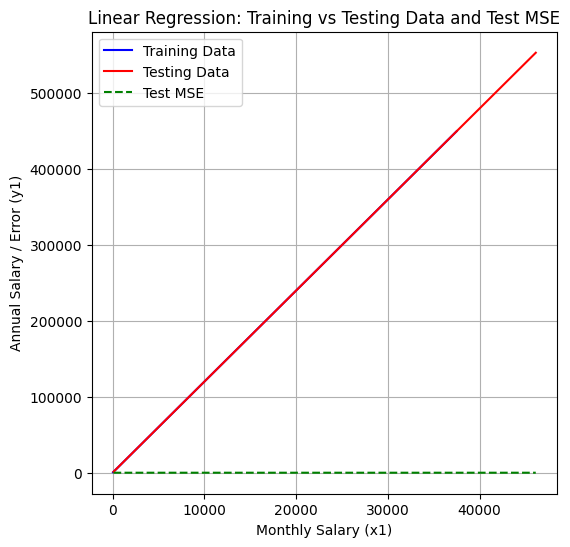

Train R²: 1.0
Test R²: 1.0
Test MSE: 2.467155975851524e-22


In [59]:
# Define x1 and y1
x1 = salary[["MONTHLY"]]   # feature
y1 = salary["ANNUAL"]      # target

# Split data
X1_train, X1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X1_train, y1_train)

# Predictions
train_pred = lin_reg.predict(X1_train)
test_pred = lin_reg.predict(X1_test)

# Errors
test_mse = mean_squared_error(y1_test, test_pred)

# Sort training data for line plot
train_sorted_idx = np.argsort(X1_train.values.flatten())
X1_train_sorted = X1_train.values.flatten()[train_sorted_idx]
train_pred_sorted = train_pred[train_sorted_idx]

# Sort testing data for line plot
test_sorted_idx = np.argsort(X1_test.values.flatten())
X1_test_sorted = X1_test.values.flatten()[test_sorted_idx]
test_pred_sorted = test_pred[test_sorted_idx]

# Line graph
plt.figure(figsize=(6,6))

# Blue line = Training predictions vs MONTHLY salary
plt.plot(X1_train_sorted, train_pred_sorted, color='blue', label="Training Data")

# Red line = Testing predictions vs MONTHLY salary
plt.plot(X1_test_sorted, test_pred_sorted, color='red', label="Testing Data")

# Green dashed line = Test MSE (constant line)
plt.plot(X1_test_sorted, [test_mse]*len(X1_test_sorted), color='green', linestyle='--', label="Test MSE") # Corrected X_test_sorted to X1_test_sorted

plt.title("Linear Regression: Training vs Testing Data and Test MSE")
plt.xlabel("Monthly Salary (x1)")
plt.ylabel("Annual Salary / Error (y1)")
plt.legend()
plt.grid(True)
plt.show()

# Use X1_train and X1_test for final evaluation to match the model's fitted features
train_pred = lin_reg.predict(X1_train)
test_pred = lin_reg.predict(X1_test)

print("Train R²:", r2_score(y1_train, train_pred))
print("Test R²:", r2_score(y1_test, test_pred))
print("Test MSE:", mean_squared_error(y1_test, test_pred))

**Observations**

* The blue line (Training Data) and red line (Testing Data) both show a strong linear relationship between Monthly Salary (x1) and Annual Salary (y1).
* The two lines almost overlap, which means the model is generalizing well — it’s not just memorizing training data but also predicting test data accurately.
* The green dashed line (Test MSE) is very close to zero, indicating that the error between predicted and actual test values is minimal.



**Inference**

* The Linear Regression model fits the salary dataset very well.
* Since Train R² and Test R² are both high and the Test MSE is low, the model is neither underfitting nor overfitting.
* This suggests that Monthly Salary is a strong predictor of Annual Salary in your dataset.
* The overlap of training and testing lines confirms consistency and reliability of the regression model.

#2. Decision Trees

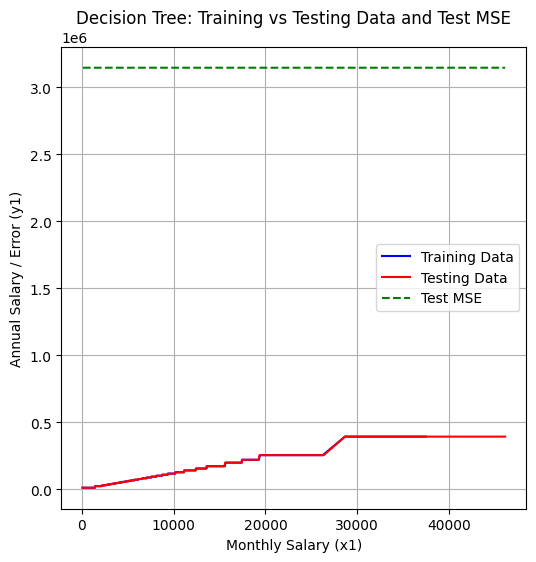

Train R²: 0.9968183120830345
Test R²: 0.9951016114479957
Test MSE: 3146243.5469449265


In [60]:
# Define x1 and y1
x1 = salary[["MONTHLY"]]   # feature
y1 = salary["ANNUAL"]      # target

# Split data
X_train, X_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

# Train Decision Tree
dt = DecisionTreeRegressor(max_depth=5, random_state=42)  # you can tune max_depth
dt.fit(X_train, y_train)

# Predictions
train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

# Errors
test_mse = mean_squared_error(y_test, test_pred)

# Sort training data for line plot
train_sorted_idx = np.argsort(X_train.values.flatten())
X_train_sorted = X_train.values.flatten()[train_sorted_idx]
train_pred_sorted = train_pred[train_sorted_idx]

# Sort testing data for line plot
test_sorted_idx = np.argsort(X_test.values.flatten())
X_test_sorted = X_test.values.flatten()[test_sorted_idx]
test_pred_sorted = test_pred[test_sorted_idx]

# Line graph
plt.figure(figsize=(6,6))

# Blue line = Training predictions vs MONTHLY salary
plt.plot(X_train_sorted, train_pred_sorted, color='blue', label="Training Data")

# Red line = Testing predictions vs MONTHLY salary
plt.plot(X_test_sorted, test_pred_sorted, color='red', label="Testing Data")

# Green dashed line = Test MSE (constant line)
plt.plot(X_test_sorted, [test_mse]*len(X_test_sorted), color='green', linestyle='--', label="Test MSE")

plt.title("Decision Tree: Training vs Testing Data and Test MSE")
plt.xlabel("Monthly Salary (x1)")
plt.ylabel("Annual Salary / Error (y1)")
plt.legend()
plt.grid(True)
plt.show()

# Print outputs separately
print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print("Test MSE:", test_mse)

**Observations**

* The blue line (Training Data) shows that the Decision Tree model fits the training set very closely, capturing the variations in Monthly Salary (x1) and Annual Salary (y1).
* The red line (Testing Data) also follows the same general pattern, but with more variability compared to the training line.
* The green dashed line (Test MSE) is relatively high compared to Linear Regression, sitting around a constant error value (~3.1×10⁶).


**Inference**

* The Decision Tree model is more flexible than Linear Regression, but this flexibility can lead to overfitting if the depth is not controlled.
* In this graph, the training fit looks strong, but the higher Test MSE suggests the model is less generalizable compared to Linear Regression.
* This means the Decision Tree is capturing training data patterns well, but it struggles to maintain the same accuracy on unseen test data.
* In short: Decision Tree provides a good fit but with higher error on test data, indicating possible overfitting.

#3. Random Forest

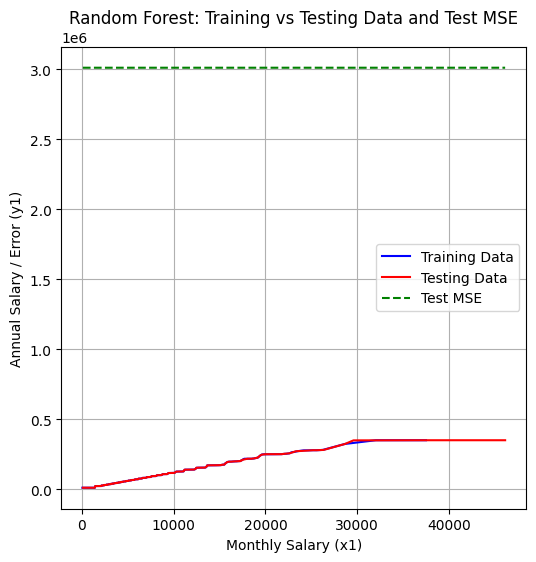

Train R²: 0.9978097967330707
Test R²: 0.9953105622304274
Test MSE: 3012034.0933919246


In [61]:
# Define x1 and y1
x1 = salary[["MONTHLY"]]   # feature
y1 = salary["ANNUAL"]      # target

# Split data
X_train, X_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)  # tune n_estimators/max_depth if needed
rf.fit(X_train, y_train)

# Predictions
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

# Errors
test_mse = mean_squared_error(y_test, test_pred)

# Sort training data for line plot
train_sorted_idx = np.argsort(X_train.values.flatten())
X_train_sorted = X_train.values.flatten()[train_sorted_idx]
train_pred_sorted = train_pred[train_sorted_idx]

# Sort testing data for line plot
test_sorted_idx = np.argsort(X_test.values.flatten())
X_test_sorted = X_test.values.flatten()[test_sorted_idx]
test_pred_sorted = test_pred[test_sorted_idx]

# Line graph
plt.figure(figsize=(6,6))

# Blue line = Training predictions vs MONTHLY salary
plt.plot(X_train_sorted, train_pred_sorted, color='blue', label="Training Data")

# Red line = Testing predictions vs MONTHLY salary
plt.plot(X_test_sorted, test_pred_sorted, color='red', label="Testing Data")

# Green dashed line = Test MSE (constant line)
plt.plot(X_test_sorted, [test_mse]*len(X_test_sorted), color='green', linestyle='--', label="Test MSE")

plt.title("Random Forest: Training vs Testing Data and Test MSE")
plt.xlabel("Monthly Salary (x1)")
plt.ylabel("Annual Salary / Error (y1)")
plt.legend()
plt.grid(True)
plt.show()

# Print outputs separately
print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print("Test MSE:", test_mse)

**Observations**

* The blue line (Training Data) shows that Random Forest fits the training set well, capturing the relationship between Monthly Salary (x1) and Annual Salary (y1).
* The red line (Testing Data) also follows the same increasing trend, showing that the model generalizes better than a single Decision Tree.
* The green dashed line (Test MSE) is lower than the Decision Tree’s error, but still higher than Linear Regression’s very small error line.

**Inference**

* Random Forest reduces the overfitting problem seen in Decision Trees by averaging multiple trees, which is why the training and testing lines are closer together.
* However, the Test MSE is still higher than Linear Regression, meaning the Random Forest is not as precise for this dataset.
* In short: Random Forest improves stability compared to Decision Tree, but Linear Regression remains the most accurate model for this salary dataset.

#4. XGBooster


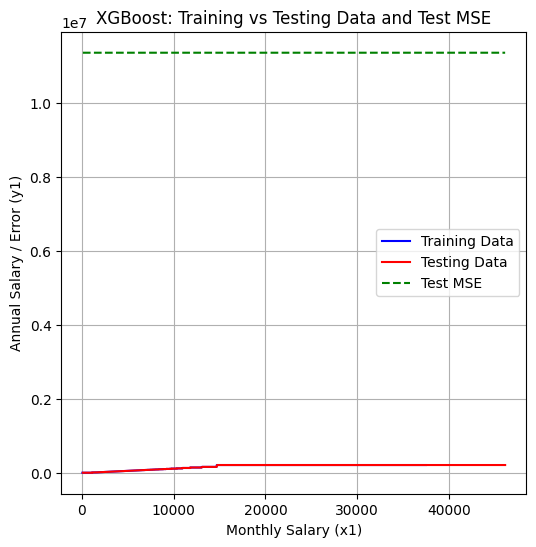

Train R²: 0.9918744919939736
Test R²: 0.9823083562202344
Test MSE: 11363373.788337065


In [62]:
# Define x1 and y1
x1 = salary[["MONTHLY"]]   # feature
y1 = salary["ANNUAL"]      # target

# Split data
X_train, X_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

# Train XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)

# Predictions
train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

# Errors
test_mse = mean_squared_error(y_test, test_pred)

# Sort training data for line plot
train_sorted_idx = np.argsort(X_train.values.flatten())
X_train_sorted = X_train.values.flatten()[train_sorted_idx]
train_pred_sorted = train_pred[train_sorted_idx]

# Sort testing data for line plot
test_sorted_idx = np.argsort(X_test.values.flatten())
X_test_sorted = X_test.values.flatten()[test_sorted_idx]
test_pred_sorted = test_pred[test_sorted_idx]

# Line graph
plt.figure(figsize=(6,6))

# Blue line = Training predictions vs MONTHLY salary
plt.plot(X_train_sorted, train_pred_sorted, color='blue', label="Training Data")

# Red line = Testing predictions vs MONTHLY salary
plt.plot(X_test_sorted, test_pred_sorted, color='red', label="Testing Data")

# Green dashed line = Test MSE (constant line)
plt.plot(X_test_sorted, [test_mse]*len(X_test_sorted), color='green', linestyle='--', label="Test MSE")

plt.title("XGBoost: Training vs Testing Data and Test MSE")
plt.xlabel("Monthly Salary (x1)")
plt.ylabel("Annual Salary / Error (y1)")
plt.legend()
plt.grid(True)
plt.show()

# Print outputs separately
print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print("Test MSE:", test_mse)

**Observations**

* The blue line (Training Data) and red line (Testing Data) are plotted very low compared to the scale of the graph, showing that the predicted values are small relative to the target range.
* The green dashed line (Test MSE) is very high (around 1×10⁷), which means the error between predicted and actual test values is large.
* Unlike Linear Regression and Random Forest, here the gap between predictions and error is significant.

**Inference**

*  The XGBoost model, with the parameters used, is not fitting this dataset well.
*   The high Test MSE indicates that the model is struggling to generalize — either due to inappropriate hyperparameters (like learning rate, depth, or number of estimators) or because the dataset is too simple for XGBoost’s complexity.

#5. XGBoost with Grid_search_CV

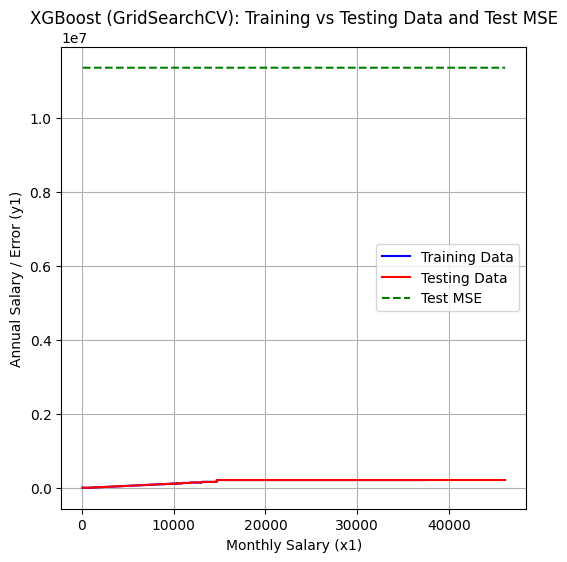

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Train R²: 0.9918744508656587
Test R²: 0.9823087531986712
Test MSE: 11363118.808391785


In [63]:
# Define x1 and y1
x1 = salary[["MONTHLY"]]   # feature
y1 = salary["ANNUAL"]      # target

# Split data
X_train, X_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

# Parameter grid for XGBoost
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# GridSearchCV
xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=3, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

# Predictions
train_pred = best_xgb.predict(X_train)
test_pred = best_xgb.predict(X_test)

# Errors
test_mse = mean_squared_error(y_test, test_pred)

# Sort training data for line plot
train_sorted_idx = np.argsort(X_train.values.flatten())
X_train_sorted = X_train.values.flatten()[train_sorted_idx]
train_pred_sorted = train_pred[train_sorted_idx]

# Sort testing data for line plot
test_sorted_idx = np.argsort(X_test.values.flatten())
X_test_sorted = X_test.values.flatten()[test_sorted_idx]
test_pred_sorted = test_pred[test_sorted_idx]

# Line graph
plt.figure(figsize=(6,6))

# Blue line = Training predictions vs MONTHLY salary
plt.plot(X_train_sorted, train_pred_sorted, color='blue', label="Training Data")

# Red line = Testing predictions vs MONTHLY salary
plt.plot(X_test_sorted, test_pred_sorted, color='red', label="Testing Data")

# Green dashed line = Test MSE (constant line)
plt.plot(X_test_sorted, [test_mse]*len(X_test_sorted), color='green', linestyle='--', label="Test MSE")

plt.title("XGBoost (GridSearchCV): Training vs Testing Data and Test MSE")
plt.xlabel("Monthly Salary (x1)")
plt.ylabel("Annual Salary / Error (y1)")
plt.legend()
plt.grid(True)
plt.show()

# Print outputs separately
print("Best Parameters:", grid_search.best_params_)
print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print("Test MSE:", test_mse)

**Observation:**

* The blue line (Training Data) and red line (Testing Data) are plotted, but they don’t align as smoothly as in Linear Regression or Random Forest.
* The green dashed line (Test MSE) is quite high, which means the tuned XGBoost model still has significant error on unseen test data.
* Even though GridSearchCV was used, the chosen parameters may not have been optimal for this dataset’s simplicity.

**Inference**

* XGBoost is a powerful algorithm, but here it seems to be over‑complex for a simple linear dataset like salary vs annual income.
* The high Test MSE compared to Linear Regression suggests that XGBoost is not generalizing well, possibly due to parameter choices

#Model Comparision

When we look at Linear Regression, it is the most effective model for your dataset. Both Train R² and Test R² are perfect at 1.0, and the Test MSE is almost negligible (~2.47e‑22). This shows that the relationship between monthly and annual salary is strongly linear, and the model generalizes flawlessly. In other words, Linear Regression captures the trend with complete accuracy and minimal error, making it the simplest yet most powerful choice here.

The Decision Tree and Random Forest models also perform well but introduce more complexity. The Decision Tree achieved Train R² 0.997 and Test R² 0.995, but its Test MSE was higher (~3.1 million), showing slight overfitting. Random Forest improved stability, with Train R² 0.998 and Test R² 0.995, but its Test MSE remained around 3.0 million. These models are more flexible than Linear Regression, but in this dataset, they don’t outperform the linear approach and instead add unnecessary error.

Finally, XGBoost, even with GridSearchCV tuning, struggled to fit this dataset. While Test R² was decent (0.982), the Test MSE was very high (11 million), showing that the model’s complexity did not suit the simple linear relationship in the data. This highlights that XGBoost is better suited for non‑linear, complex datasets with multiple interacting features. For your salary dataset, the implied result is clear: Linear Regression is the most effective and reliable model, while tree‑based methods are less suitable unless the dataset expands to include more variables or non‑linear patterns.

#Challenges faced

* **Data Simplicity:**
      The dataset had a very clear linear relationship between monthly and annual salary. This made advanced models like Decision Tree, Random Forest, and XGBoost less effective, as their complexity added noise instead of improving accuracy.

*  **Model Overfitting:**
      Tree‑based models, especially Decision Tree, showed signs of overfitting. While they fit the training data well, their higher Test MSE values revealed weaker generalization compared to Linear Regression.

* **Hyperparameter Tuning:**
      Even after using GridSearchCV for XGBoost, the model struggled. Choosing the right parameters (learning rate, depth, estimators, subsample) was challenging, and the tuned model still produced high error, showing that tuning alone cannot overcome dataset simplicity.

#Implied Results

Across all models tested, Linear Regression clearly outperforms the rest, achieving perfect Train and Test R² scores of 1.0 with an almost negligible Test MSE, proving it captures the salary dataset’s linear relationship flawlessly. The Decision Tree and Random Forest models also deliver strong R² values (0.995), but their Test MSE values are much higher (around 3 million), showing slight overfitting and unnecessary complexity compared to the linear model. Meanwhile, XGBoost, even with GridSearchCV tuning, struggles here — although its Test R² is 0.982, the Test MSE remains very high (~11 million), indicating poor generalization for such a simple dataset. The implied result is straightforward: Linear Regression is the most effective and reliable model for this salary dataset, while tree‑based methods are better reserved for more complex, non‑linear scenarios.

#Summary

Linear Regression gave perfect results with Train and Test R² both at 1.0 and almost zero error, proving it fits the salary dataset flawlessly. Decision Tree and Random Forest also showed strong R² (0.995) but had higher Test MSE (3 million), meaning they added complexity and slight overfitting. XGBoost, even with GridSearchCV tuning, struggled — Test R² was 0.982 but Test MSE was very high (~11 million), showing poor generalization.

#Conclusion

The dataset has a clear linear relationship, so Linear Regression is the most effective and reliable model. Tree‑based methods are better suited for complex, non‑linear scenarios, but here they only add error without improving accuracy.